In [1]:
import triton
from unsloth import FastLanguageModel

max_seq_length = 4096
load_in_4bit = False 

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = max_seq_length,
    dtype = "float16",
    load_in_4bit = load_in_4bit,
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/euskov10/TritonInt8Compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.566 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 146/146 [00:00<00:00, 266.96it/s]
Unsloth: Will load unsloth/Llama-3.2-1B-Instruct as a legacy tokenizer.


In [2]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048, padding_idx=128004)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)

In [3]:
weights = [
    model.model.layers[0].self_attn.q_proj.weight.to('cuda'),
    model.model.layers[0].self_attn.k_proj.weight.to('cuda'),
    model.model.layers[0].mlp.gate_proj.weight.to('cuda'),
    model.model.layers[0].mlp.down_proj.weight.to('cuda'),
]

In [4]:
for weight in weights:
    print(weight.shape)

torch.Size([2048, 2048])
torch.Size([512, 2048])
torch.Size([8192, 2048])
torch.Size([2048, 8192])


In [9]:
from kernels.compression_int4 import quant_compress_to_int4 
import torch

import torch.nn as nn

linears = []
for weight in weights:
    linear = nn.Linear(weight.shape[1], weight.shape[0], bias=False, dtype=torch.float16).to('cuda')
    linear.data = weight.data
    linears.append(linear)
    
@torch.no_grad()
def benchmark_quant_gemm(M, quant_block_size, i, provider, provider_funcs):
    weight = weights[i]
    linear = linears[i]
    N, K = weight.shape

    x = torch.randn((M, K), dtype=torch.float16, device='cuda')
    weight_comp8, scale8 = quant_compress_to_int4(weight, compress_factor=8, quant_block_size=quant_block_size)
    weight_comp2, scale2 = quant_compress_to_int4(weight, compress_factor=2, quant_block_size=quant_block_size)

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(
        lambda: provider_funcs[provider](x, weight, weight_comp2, scale2, weight_comp8, scale8, linear), quantiles=quantiles)
    perf = lambda ms: ms # TFlops = 2 * M * N * K * 1e-12 / (ms * 1e-3)
    
    # print(f"[Live] M={M:^5} | Quant block size={quant_block_size:^5} | N={N:^5} | K={K:^5} | {provider}: {ms:.4f} ms", flush=True)
    return perf(ms), perf(max_ms), perf(min_ms)

In [6]:
@torch.compile
def matmul_compile(a, b):
    return torch.matmul(a, b.T)

In [18]:
from kernels.decompress_int4_matmul_float16_fused import decompress_int4_matmul_float16_fused



configs = [
    *[
        triton.testing.Benchmark(
            x_names=["M"],  # Argument names to use as an x-axis for the plot
            x_vals=[1, 2, 4],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            line_vals=["matmul torch", "triton compress 8", "triton compress 2", 'nn.Linear', 'matmul compile'],  # Label name for the lines
            line_names=["Torch", "Triton Uint32", "Triton Uint8", "Linear", "Compile"],  # Line styles
            styles=[("green", "-"), ("blue", "-"), ("red", "-"), ("orange", "-"), ("purple", "-")],
            ylabel="ms",  # Label name for the y-axis
            plot_name=f"GeMV-performance on {weights[i].shape}",  # Name for the plot, used also as a file name for saving the plot.
            args={
                "provider_funcs": {
                    "triton compress 8": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(e, f, a), 
                    "triton compress 2": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(c, d, a), 
                    "matmul torch": lambda a, b, c, d, e, f, l: torch.matmul(a, b.T),
                    "nn.Linear": lambda a, b, c, d, e, f, l: l(a),
                    "matmul compile": lambda a, b, c, d, e, f, l: matmul_compile(a, b)
                },
                "quant_block_size": 64,
                "i": i,
            },
        )   
        for i in range(len(weights) -  1)
    ],
    *[
        triton.testing.Benchmark(
            x_names=["quant_block_size"],  # Argument names to use as an x-axis for the plot
            x_vals=[16, 32, 64, 128],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            line_vals=["triton compress 8", "triton compress 2"],  # Label name for the lines
            line_names=["Triton Uint32", "Triton Uint8"],  # Line styles
            styles=[("green", "-"), ("blue", "-")],
            ylabel="ms",  # Label name for the y-axis
            plot_name=f"GeMV-performance by quant_blocks_size on {weights[i].shape}",  # Name for the plot, used also as a file name for saving the plot.
            args={
                "provider_funcs": {
                    "triton compress 8": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(e, f, a), 
                    "triton compress 2": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(c, d, a), 
                },
                "M": 1,
                "i": i,
            },
        )
        for i in range(len(weights) - 1)
    ]
]

In [19]:
triton.testing.perf_report(configs)(benchmark_quant_gemm).run(show_plots=True, print_data=True, save_path='./plots')

GeMV-performance on torch.Size([2048, 2048]):
     M  Torch (ms)  Triton Uint32 (ms)  Triton Uint8 (ms)  Linear (ms)  Compile (ms)
0  1.0    0.054256            0.055280           0.032768     0.042912      0.041232
1  2.0    0.057056            0.047104           0.032256     0.056768      0.057088
2  4.0    0.057152            0.118784           0.047232     0.056736      0.056992
GeMV-performance on torch.Size([512, 2048]):
     M  Torch (ms)  Triton Uint32 (ms)  Triton Uint8 (ms)  Linear (ms)  Compile (ms)
0  1.0    0.015840            0.026848           0.024800     0.015296      0.015968
1  2.0    0.018336            0.027488           0.036608     0.018240      0.018336
2  4.0    0.018432            0.027376           0.023936     0.018432      0.018432


/home/euskov10/TritonInt8Compression/.venv/lib/python3.14/site-packages/triton/testing.py:350: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


GeMV-performance on torch.Size([8192, 2048]):
     M  Torch (ms)  Triton Uint32 (ms)  Triton Uint8 (ms)  Linear (ms)  Compile (ms)
0  1.0    0.141536            0.110752           0.095712     0.141088      0.141312
1  2.0    0.154144            0.182944           0.116960     0.153920      0.154464
2  4.0    0.155136            0.262336           0.138720     0.154656      0.155328
GeMV-performance by quant_blocks_size on torch.Size([2048, 2048]):
   quant_block_size  Triton Uint32 (ms)  Triton Uint8 (ms)
0              16.0            0.041712           0.036864
1              32.0            0.038064           0.034176
2              64.0            0.035168           0.031472
3             128.0            0.054016           0.025792
GeMV-performance by quant_blocks_size on torch.Size([512, 2048]):
   quant_block_size  Triton Uint32 (ms)  Triton Uint8 (ms)
0              16.0            0.032768           0.027168
1              32.0            0.033312           0.024576
2        

[Live] M=  1   | Quant block size= 16   | N=2048  | K=2048  | triton compress 8: 0.0733 ms
[Live] M=  1   | Quant block size= 16   | N=2048  | K=2048  | triton compress 2: 0.0464 ms
[Live] M=  1   | Quant block size= 32   | N=2048  | K=2048  | triton compress 8: 0.0451 ms
[Live] M=  1   | Quant block size= 32   | N=2048  | K=2048  | triton compress 2: 0.0348 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | triton compress 8: 0.0347 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | triton compress 2: 0.0327 ms
[Live] M=  1   | Quant block size= 128  | N=2048  | K=2048  | triton compress 8: 0.0542 ms
[Live] M=  1   | Quant block size= 128  | N=2048  | K=2048  | triton compress 2: 0.0257 ms


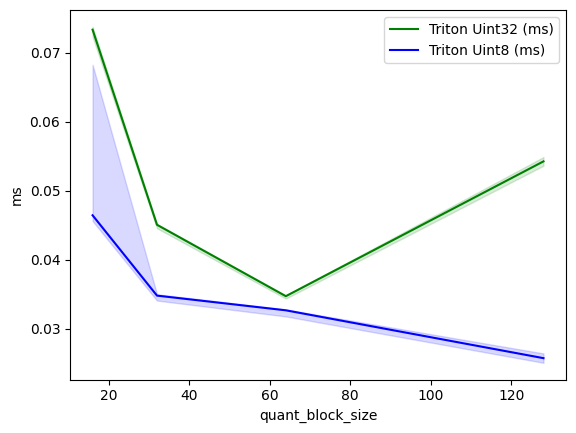

GeMV-performance-fp16:
   quant_block_size  Triton Uint32 (ms)  Triton Uint8 (ms)
0              16.0            0.073312           0.046432
1              32.0            0.045056           0.034800
2              64.0            0.034720           0.032672
3             128.0            0.054240           0.025744
[Live] M=  1   | Quant block size= 16   | N= 512  | K=2048  | triton compress 8: 0.0559 ms
[Live] M=  1   | Quant block size= 16   | N= 512  | K=2048  | triton compress 2: 0.0281 ms
[Live] M=  1   | Quant block size= 32   | N= 512  | K=2048  | triton compress 8: 0.0332 ms
[Live] M=  1   | Quant block size= 32   | N= 512  | K=2048  | triton compress 2: 0.0263 ms
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | triton compress 8: 0.0284 ms
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | triton compress 2: 0.0259 ms
[Live] M=  1   | Quant block size= 128  | N= 512  | K=2048  | triton compress 8: 0.0574 ms
[Live] M=  1   | Quant block size= 128  | N= 

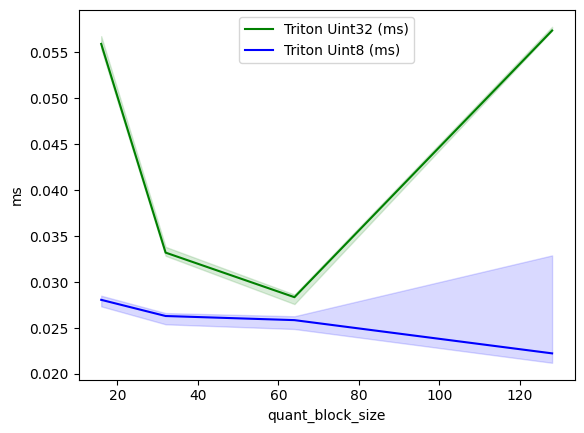

GeMV-performance-fp16:
   quant_block_size  Triton Uint32 (ms)  Triton Uint8 (ms)
0              16.0            0.055904           0.028064
1              32.0            0.033200           0.026304
2              64.0            0.028352           0.025856
3             128.0            0.057360           0.022240
[Live] M=  1   | Quant block size= 16   | N=8192  | K=2048  | triton compress 8: 0.1279 ms
[Live] M=  1   | Quant block size= 16   | N=8192  | K=2048  | triton compress 2: 0.1665 ms
[Live] M=  1   | Quant block size= 32   | N=8192  | K=2048  | triton compress 8: 0.1061 ms
[Live] M=  1   | Quant block size= 32   | N=8192  | K=2048  | triton compress 2: 0.1178 ms
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | triton compress 8: 0.1188 ms
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | triton compress 2: 0.0970 ms
[Live] M=  1   | Quant block size= 128  | N=8192  | K=2048  | triton compress 8: 0.1161 ms
[Live] M=  1   | Quant block size= 128  | N=8

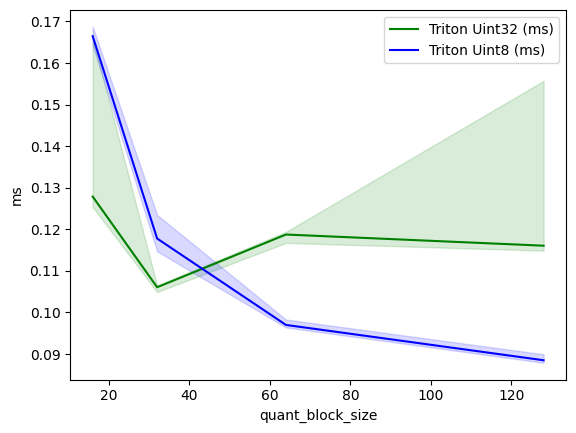

GeMV-performance-fp16:
   quant_block_size  Triton Uint32 (ms)  Triton Uint8 (ms)
0              16.0            0.127872           0.166464
1              32.0            0.106080           0.117792
2              64.0            0.118752           0.097008
3             128.0            0.116064           0.088512


In [ ]:
triton.testing.perf_report(configs)(benchmark_quant_gemm).run(show_plots=True, print_data=True)